# **Projeto de IA - Aprendizado de Máquina**

**Grupo:**

Gabriel Negreiro Oliveira

Marcello Ryaj de Almeida Santos

Mateus Levi Morais Feitosa

## **O conjunto de dados**

O conjunto de dados utilizado neste projeto é o mfeat-zernike, que faz parte do conjunto Multiple Features, disponibilizado pelo UCI Machine Learning Repository. Seu objetivo é classificar dígitos manuscritos em dez classes, correspondentes aos números de 0 a 9. 
 
Cada instância representa um dígito manuscrito, escrito à mão e extraído de uma coleção de mapas de serviços públicos holandeses. Cada imagem foi convertida em uma representação binária e, a partir dela, foram obtidos momentos de Zernike que descrevem características de sua forma.

In [1]:
!pip install seaborn

In [2]:
# Bibliotecas para trabalhar com tabelas e valores numéricos
import numpy as np
import pandas as pd

# Importa as ferramentas para padronização e PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Biblioteca para carregar o arquivo no formato ARFF
from scipy.io import arff

# Bibliotecas para geração de gráficos
import matplotlib.pyplot as plt

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [3]:
# Carrega os dados do arquivo ARFF
dados, metadados = arff.loadarff("dataset_22_mfeat-zernike.arff")

# Converte os dados para uma tabela
df = pd.DataFrame(dados)

# Converte os rótulos das classes para números inteiros
df["class"] = df["class"].str.decode("utf-8").astype(int)

# Mostra as cinco primeiras instâncias
df.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att39,att40,att41,att42,att43,att44,att45,att46,att47,class
0,0.011033,0.831466,15.351804,75.806559,171.554214,490.156556,206.416027,0.122135,2.601646,11.472709,...,33.810340,9.858915,1.399891,148.138058,326.239452,9.711070,20.007248,47.032578,539.208457,1
1,0.038271,1.166746,10.526913,42.369276,85.187116,420.360566,253.569574,0.033657,0.390566,11.700830,...,35.400531,70.681899,6.674412,155.135985,377.832675,8.140633,44.536711,46.338954,518.496567,1
2,0.042698,1.225007,8.273804,31.744786,54.448177,404.103204,389.980746,0.041733,0.937399,11.629045,...,19.477230,30.093590,7.858211,150.126419,419.565747,4.530921,26.292170,44.574822,549.912691,1
3,0.032418,1.638247,19.205283,51.196682,57.181760,429.052011,256.174645,0.073624,1.973268,13.057108,...,14.179518,30.564085,7.097728,173.840759,441.350376,3.706023,13.432311,51.739930,574.887814,1
4,0.015866,0.611561,8.627839,37.325052,48.509025,459.909634,238.572767,0.046477,1.117292,10.012169,...,8.705403,30.242473,9.015714,167.021185,332.479997,1.806273,23.689300,50.407770,492.227513,1


In [4]:
# Verifica o número de instâncias e colunas
print("Dimensão do conjunto:", df.shape)

# Verifica a quantidade de exemplos em cada classe
print("\nQuantidade de instâncias por classe:")
print(df["class"].value_counts().sort_index())

# Verifica se existem valores ausentes
print("\nQuantidade de valores ausentes:", df.isnull().sum().sum())

# Verifica se existem linhas repetidas
print("Quantidade de instâncias duplicadas:", df.duplicated().sum())

Dimensão do conjunto: (2000, 48)

Quantidade de instâncias por classe:
class
1     200
2     200
3     200
4     200
5     200
6     200
7     200
8     200
9     200
10    200
Name: count, dtype: int64

Quantidade de valores ausentes: 0
Quantidade de instâncias duplicadas: 6


In [5]:
# Cria uma tabela com as principais características do conjunto
resumo = pd.DataFrame({
    "Característica": [
        "Nome do conjunto",
        "Número de instâncias",
        "Número de atributos",
        "Tipo dos atributos",
        "Número de classes",
        "Distribuição das classes",
        "Valores ausentes"
    ],
    "Valor": [
        "mfeat-zernike",
        "2.000",
        "47",
        "Numéricos contínuos",
        "10",
        "200 instâncias por classe",
        "Não há"
    ]
})



O conjunto possui 2.000 instâncias, 47 atributos numéricos e dez classes balanceadas, com 200 exemplos em cada classe. Não há valores ausentes. Os atributos apresentam escalas distintas, aspecto que será considerado no pré-processamento dos modelos. No arquivo, a coluna class aparece com valores entre 1 e 10; essa é apenas uma codificação dos rótulos das dez classes de dígitos.

## **Análise exploratória dos dados**

Nesta seção, são apresentadas estatísticas descritivas e visualizações dos atributos do conjunto, com o objetivo de identificar padrões, escalas, dispersões e relações entre as classes.

In [6]:
# Separa os 47 atributos da coluna de classe
X = df.drop(columns="class")

# Calcula estatísticas descritivas para cada atributo
estatisticas = X.describe().T

# Exibe a tabela
estatisticas

,count,mean,std,min,25%,50%,75%,max
att1,2000.0,0.078554,0.066552,0.001094,0.032160,0.057027,0.106162,0.496841
att2,2000.0,1.764332,1.159269,0.032385,0.928543,1.550141,2.360365,9.363772
att3,2000.0,21.708127,11.728827,0.364935,12.391974,20.868980,29.715504,72.443632
att4,2000.0,69.881897,38.348810,2.240865,40.587107,63.220758,94.255601,200.558005
att5,2000.0,109.519676,53.202068,3.822781,69.938353,106.643071,143.995104,284.648888
att6,2000.0,266.027267,124.192494,1.937737,166.395919,258.039088,360.421939,563.061573
att7,2000.0,147.578565,100.397369,0.045660,60.878624,132.145970,220.408564,463.128264
att8,2000.0,0.117313,0.086653,0.002745,0.053369,0.094367,0.162198,0.629253
att9,2000.0,2.612039,1.615522,0.073840,1.362552,2.361967,3.526661,13.115040
att10,2000.0,24.564107,17.233333,0.559946,11.906010,20.464571,32.672407,92.652118


In [7]:
# Resume os valores gerais encontrados entre todos os atributos
print("Menor valor do conjunto:", X.min().min())
print("Maior valor do conjunto:", X.max().max())
print("Menor desvio padrão:", X.std().min())
print("Maior desvio padrão:", X.std().max())

Menor valor do conjunto: 0.00109432
Maior valor do conjunto: 777.86182699
Menor desvio padrão: 0.06655200271465168
Maior desvio padrão: 124.19249364407261


As estatísticas descritivas mostram que os atributos possuem escalas e dispersões bastante distintas. Enquanto o menor valor observado no conjunto é aproximadamente 0,001, o maior chega a 777,862. Além disso, os desvios padrão variam de 0,067 a 124,192. Portanto, alguns atributos apresentam uma variação muito maior que outros, o que justifica a aplicação de padronização antes do treinamento de modelos sensíveis à escala dos dados.

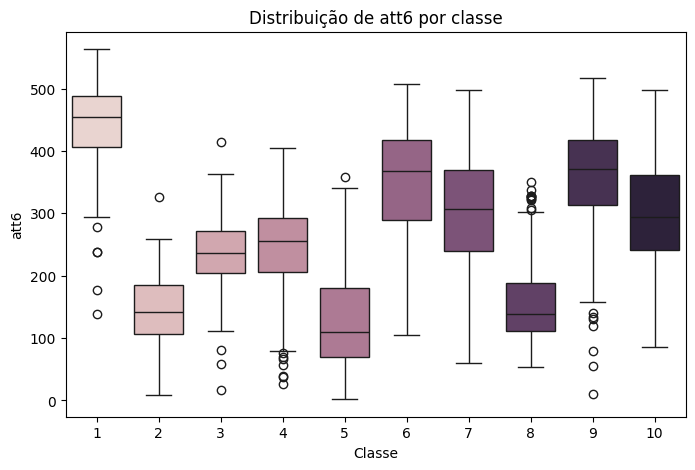

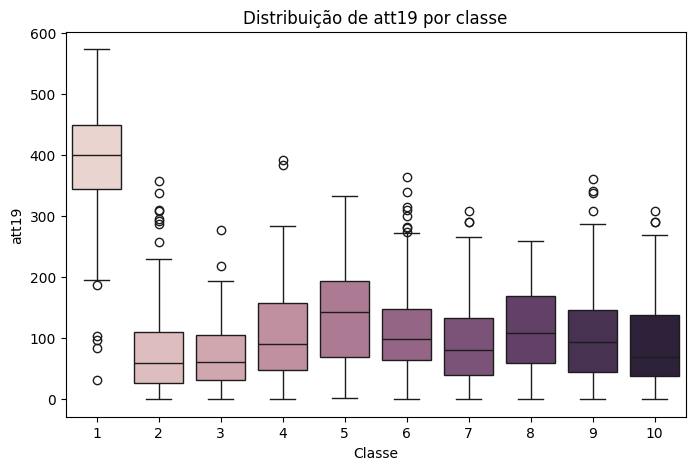

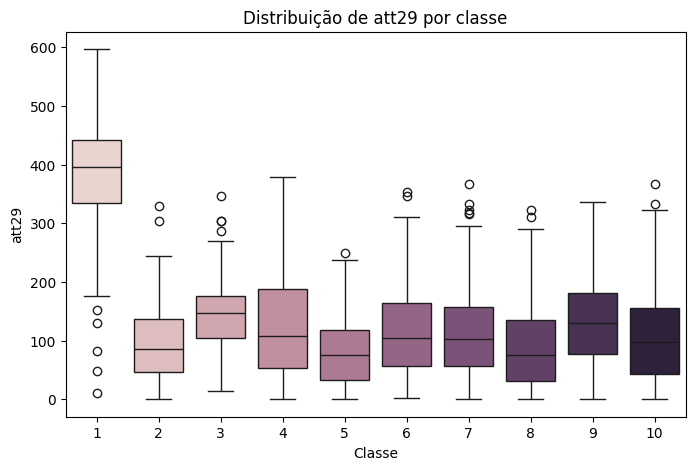

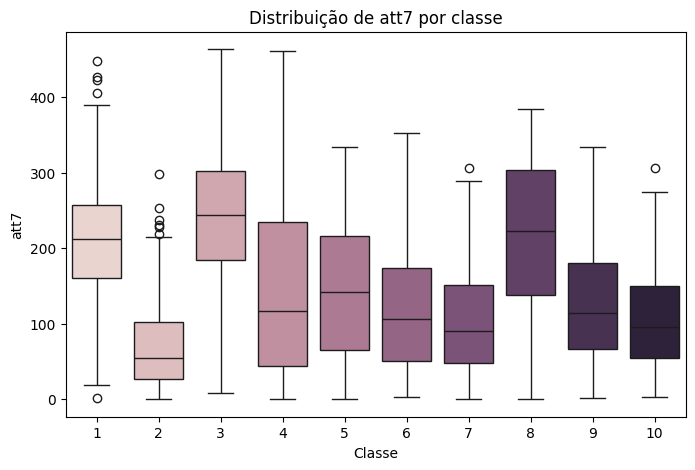

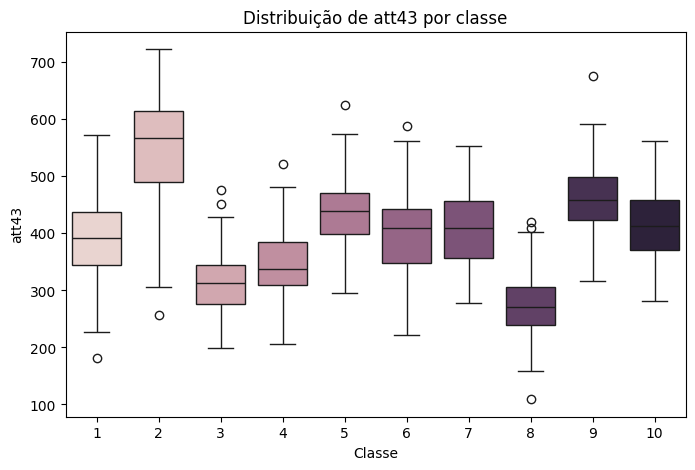

In [8]:
# Importa a biblioteca para os gráficos
import seaborn as sns

# Seleciona os cinco atributos com maior desvio padrão
atributos_selecionados = X.std().nlargest(5).index

# Cria um boxplot para cada atributo selecionado
for atributo in atributos_selecionados:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        x="class",
        y=atributo,
        data=df,
        hue="class",
        legend=False
    )
    
    plt.title(f"Distribuição de {atributo} por classe")
    plt.xlabel("Classe")
    plt.ylabel(atributo)
    plt.show()

Os boxplots dos cinco atributos selecionados mostram que as classes apresentam diferenças em suas medianas e dispersões. Nos atributos att6, att19 e att29, a classe 1 se destaca por apresentar valores centrais mais elevados que grande parte das demais classes. No atributo att43, a classe 2 possui mediana mais alta, enquanto a classe 8 concentra valores menores. Já em att7, algumas classes também apresentam faixas distintas, embora haja maior sobreposição entre as distribuições. Os pontos fora das hastes representam observações afastadas do padrão típico de suas classes. De modo geral, os gráficos indicam que os atributos contribuem para diferenciar alguns grupos de dígitos, mas as sobreposições mostram que a classificação depende da combinação dos 47 atributos.

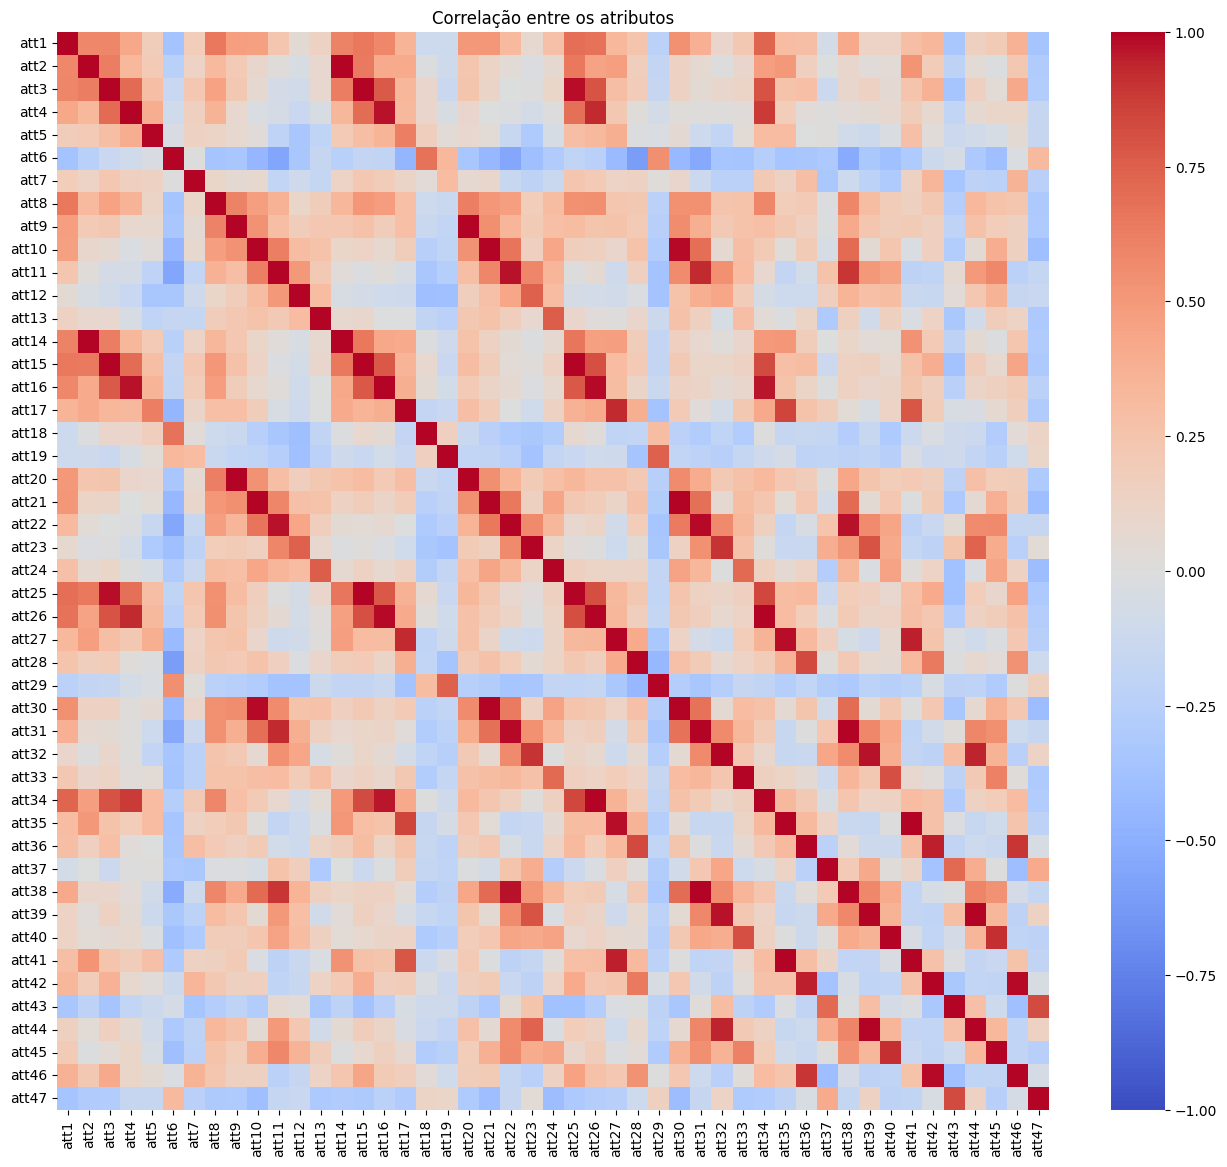

In [9]:
# Matriz de correlação entre os atributos
df_correlation = df[df.columns.drop("class")].corr()

# Cria o heatmap
plt.figure(figsize=(16, 14))

sns.heatmap(
    df_correlation,
    xticklabels=df_correlation.columns,
    yticklabels=df_correlation.columns,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlação entre os atributos")
plt.show()

A diagonal principal apresenta correlação igual a 1, pois cada atributo é perfeitamente correlacionado com ele mesmo. Fora da diagonal, observam-se blocos em tons de vermelho, indicando grupos de atributos com correlação positiva moderada ou forte. Também há regiões em azul, que representam relações negativas entre alguns atributos. Entretanto, grande parte da matriz apresenta cores claras, indicando correlações fracas ou moderadas. Esses padrões mostram que os momentos de Zernike não são totalmente independentes e que alguns atributos carregam informações semelhantes sobre a forma dos dígitos. A existência de atributos correlacionados será considerada na etapa de treinamento dos modelos.

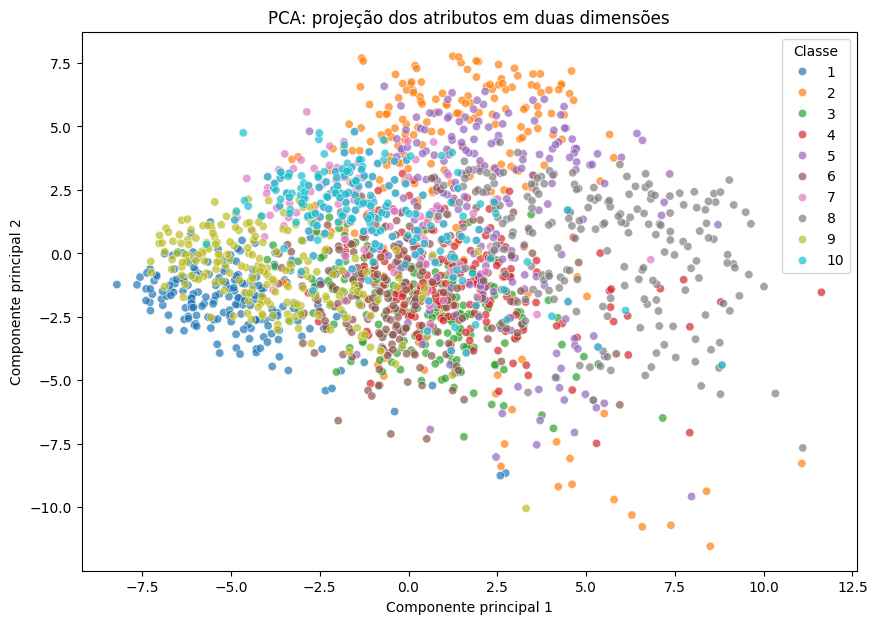

In [10]:
# Padroniza os atributos somente para a visualização por PCA
X_padronizado = StandardScaler().fit_transform(X)

# Reduz os 47 atributos para duas componentes principais
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_padronizado)

# Cria uma nova tabela para o gráfico
df_pca = pd.DataFrame(
    componentes_principais,
    columns=["Componente 1", "Componente 2"]
)

# Adiciona a classe como texto para usar cores distintas
df_pca["class"] = df["class"].astype(str)

# Cria o scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x="Componente 1",
    y="Componente 2",
    hue="class",
    palette="tab10",
    alpha=0.7
)

plt.title("PCA: projeção dos atributos em duas dimensões")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Classe")
plt.show()

A projeção por PCA reduziu os 47 atributos a duas componentes principais para permitir a visualização dos dados. O gráfico mostra que algumas classes apresentam regiões parcialmente distintas, como a classe 8, que se concentra mais à direita, a classe 1, localizada majoritariamente à esquerda, e a classe 2, que tende a ocupar regiões superiores. Entretanto, várias classes se concentram na região central e apresentam sobreposição considerável, indicando que a separação entre todos os dígitos não é completa em apenas duas dimensões. Assim, os resultados sugerem que os atributos de Zernike contêm informação para diferenciar parte das classes, mas os modelos devem utilizar a combinação dos 47 atributos para realizar uma classificação mais precisa.

In [11]:
# Calcula a porcentagem da variabilidade explicada pelas duas componentes
variancia_explicada = pca.explained_variance_ratio_ * 100

print(f"Componente principal 1: {variancia_explicada[0]:.2f}%")
print(f"Componente principal 2: {variancia_explicada[1]:.2f}%")
print(f"Total explicado pelas duas componentes: {variancia_explicada.sum():.2f}%")

Componente principal 1: 26.02%
Componente principal 2: 18.61%
Total explicado pelas duas componentes: 44.63%


As duas componentes principais explicam, juntas, aproximadamente 44.63% da variabilidade total dos atributos.

## **Pré-processamentos**

Discuta que pré-processamentos são necessários e por quê. Diga como cada um deles é implementado/usado em seu projeto.

## **Aplicando o pipeline de AM**

Nesta seção, os modelos serão avaliados com validação cruzada estratificada externa de 10 dobras. O ajuste de hiperparâmetros dos modelos será realizado internamente em cada dobra externa.

Como referência, foi utilizado um `DummyClassifier` com a estratégia `most_frequent`. Esse classificador ignora os 47 atributos e sempre prevê a classe mais frequente, estabelecendo um desempenho mínimo para comparação com os modelos treinados posteriormente.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define a validação cruzada estratificada externa com 10 dobras
cv_externa = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Cria o classificador de referência
dummy = DummyClassifier(strategy="most_frequent")

# Avalia o baseline com as mesmas métricas que serão usadas nos outros modelos
resultados_dummy = cross_validate(
    dummy,
    X,
    df["class"],
    cv=cv_externa,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"}
)

# Organiza a média e o desvio padrão das métricas
tabela_dummy = pd.DataFrame({
    "Métrica": ["Acurácia", "F1 macro"],
    "Média": [
        resultados_dummy["test_accuracy"].mean(),
        resultados_dummy["test_f1_macro"].mean()
    ],
    "Desvio padrão": [
        resultados_dummy["test_accuracy"].std(),
        resultados_dummy["test_f1_macro"].std()
    ]
})

tabela_dummy.round(3)

O `DummyClassifier` obteve acurácia de aproximadamente 0,100 e F1 macro de aproximadamente 0,018, sem variação entre as dobras. Como o conjunto possui dez classes balanceadas, o modelo acerta apenas a classe que prevê sempre. Portanto, os modelos treinados devem superar claramente esse baseline para demonstrar que aprenderam padrões dos atributos.

## **Analisando os erros**

Aqui focaremos em analisar onde as técnicas estão errando e tentar entender por que esses erros estão ocorrendo. Todo mundo erra a mesma coisa? Que características têm as instâncias em que os maiores erros são cometidos? Faça discussões.

## **Conclusões**

Quais são suas conclusões sobre os experimentos realizados? Resuma o que foi alcançado no trabalho e tente propor estratégias para trabalhos futuros com esses dados. Agradeço também se puderem dar um feedback sobre o que acharam do trabalho. E declarem explicitamente o uso de ferramentas de LLM para auxílio ao desenvolvimento do trabalho.

## **Referências**

DUIN, R. P. W. *Multiple Features* [conjunto de dados]. UCI Machine Learning Repository, 1998. DOI: 10.24432/C5HC70. Disponível em: <https://archive.ics.uci.edu/dataset/72/multiple>.

WILLEMS, Karlijn. *Python Exploratory Data Analysis Tutorial*. DataCamp, 15 mar. 2017. Disponível em: <https://www.datacamp.com/tutorial/exploratory-data-analysis-python>.

MATERIAL DA DISCIPLINA CMC-15. *Notebook de apoio para análise exploratória de dados*. Google Colab. Disponível em: <https://colab.research.google.com/drive/1jLrzNUQhx9-nOOCv0YNIyaAARQK7TtMp?usp=classroom_web#scrollTo=ehBjoRV42qXa>.